In [44]:
# Create one-hot vectors and obtain embeddings
def get_embedding(skill_id, model, num_skills):
    # Create one-hot vector as a tensor
    one_hot = torch.zeros(num_skills)
    one_hot[skill_id - 1] = 1  # Adjusting index since skill_ids_renumbered starts from 1
    # Get the embedding for the one-hot vector
    embedding = model.embedding(one_hot) # Use skill_id-1 as index for embedding
    return embedding.squeeze(0).detach().numpy()


In [45]:
# Get embeddings for each row and store them as new columns
embeddings = df_embeddings["skill_ids_renumbered"].apply(lambda x: get_embedding(x, model, num_skills))
embedding_dim = embeddings.iloc[0].shape[0]  # Dimension of embedding

# Split embedding values into individual columns
embedding_columns = [f"embed_{i+1}" for i in range(embedding_dim)]
df_embeddings[embedding_columns] = pd.DataFrame(embeddings.tolist(), index=df_embeddings.index)


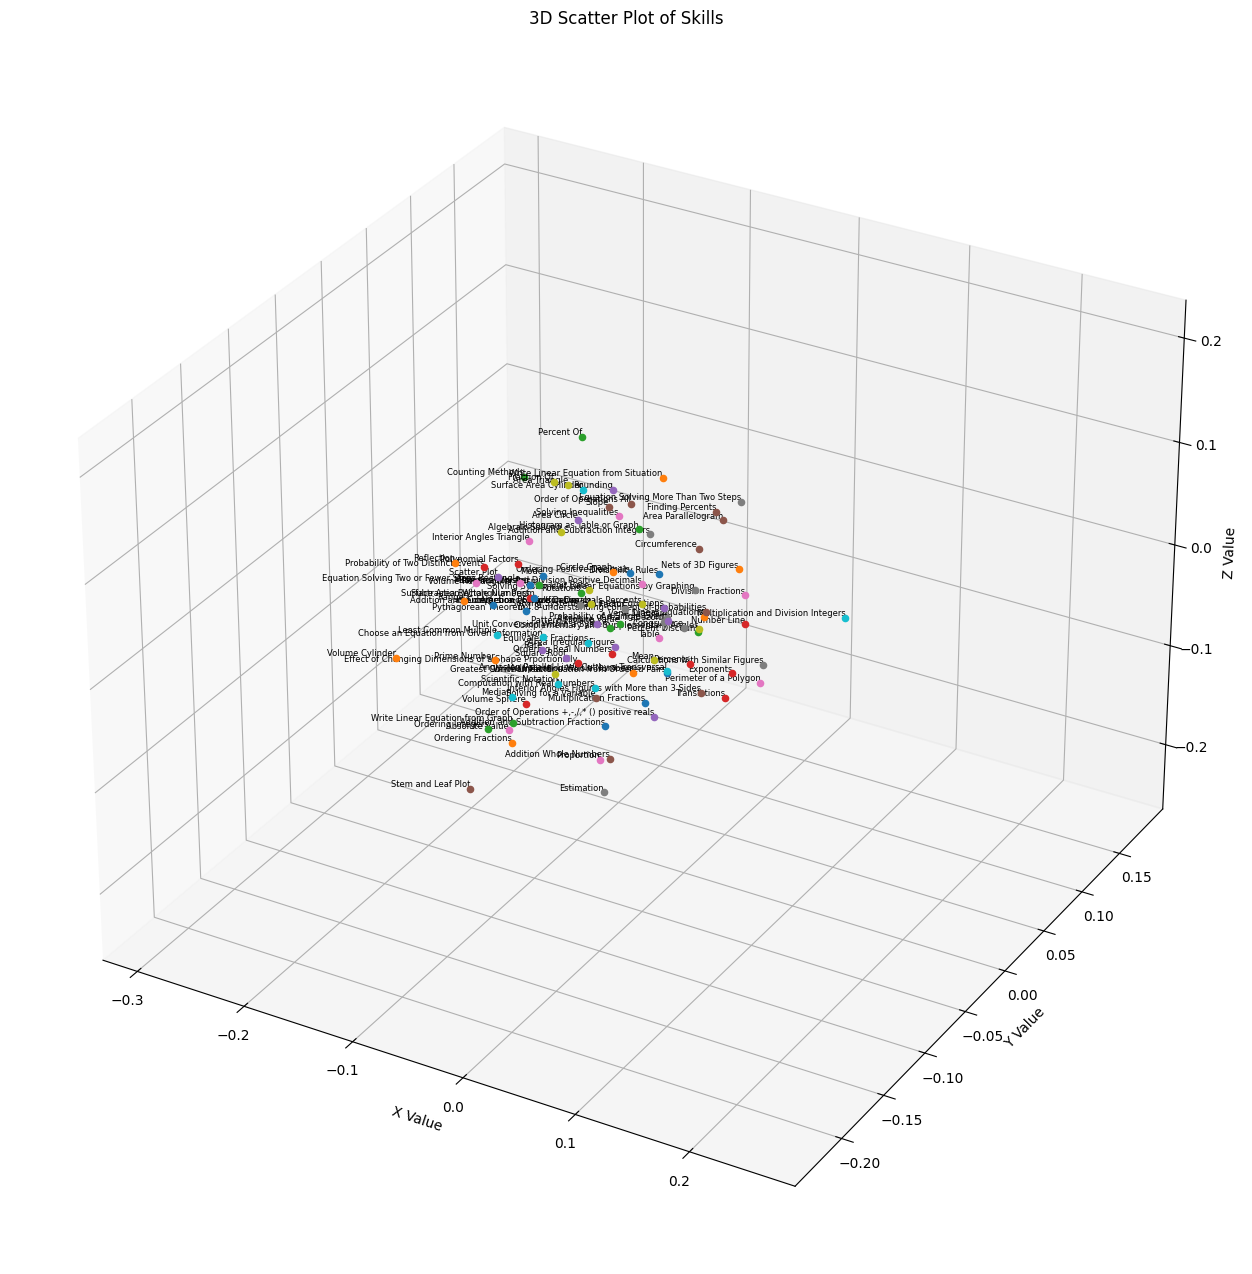

In [46]:
# Create a 3D scatter plot
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')

# Plot each point and annotate with 'skill_name'
for i, row in df_embeddings.iterrows():
    ax.scatter(row['embed_1'], row['embed_2'], row['embed_3'])  # 3D coordinates
    ax.text(row['embed_1'], row['embed_2'], row['embed_3'], row['skill_name'], fontsize=6, ha='right', va='bottom')

# Labels and title
ax.set_xlabel('X Value')
ax.set_ylabel('Y Value')
ax.set_zlabel('Z Value')
ax.set_title('3D Scatter Plot of Skills')

plt.show()


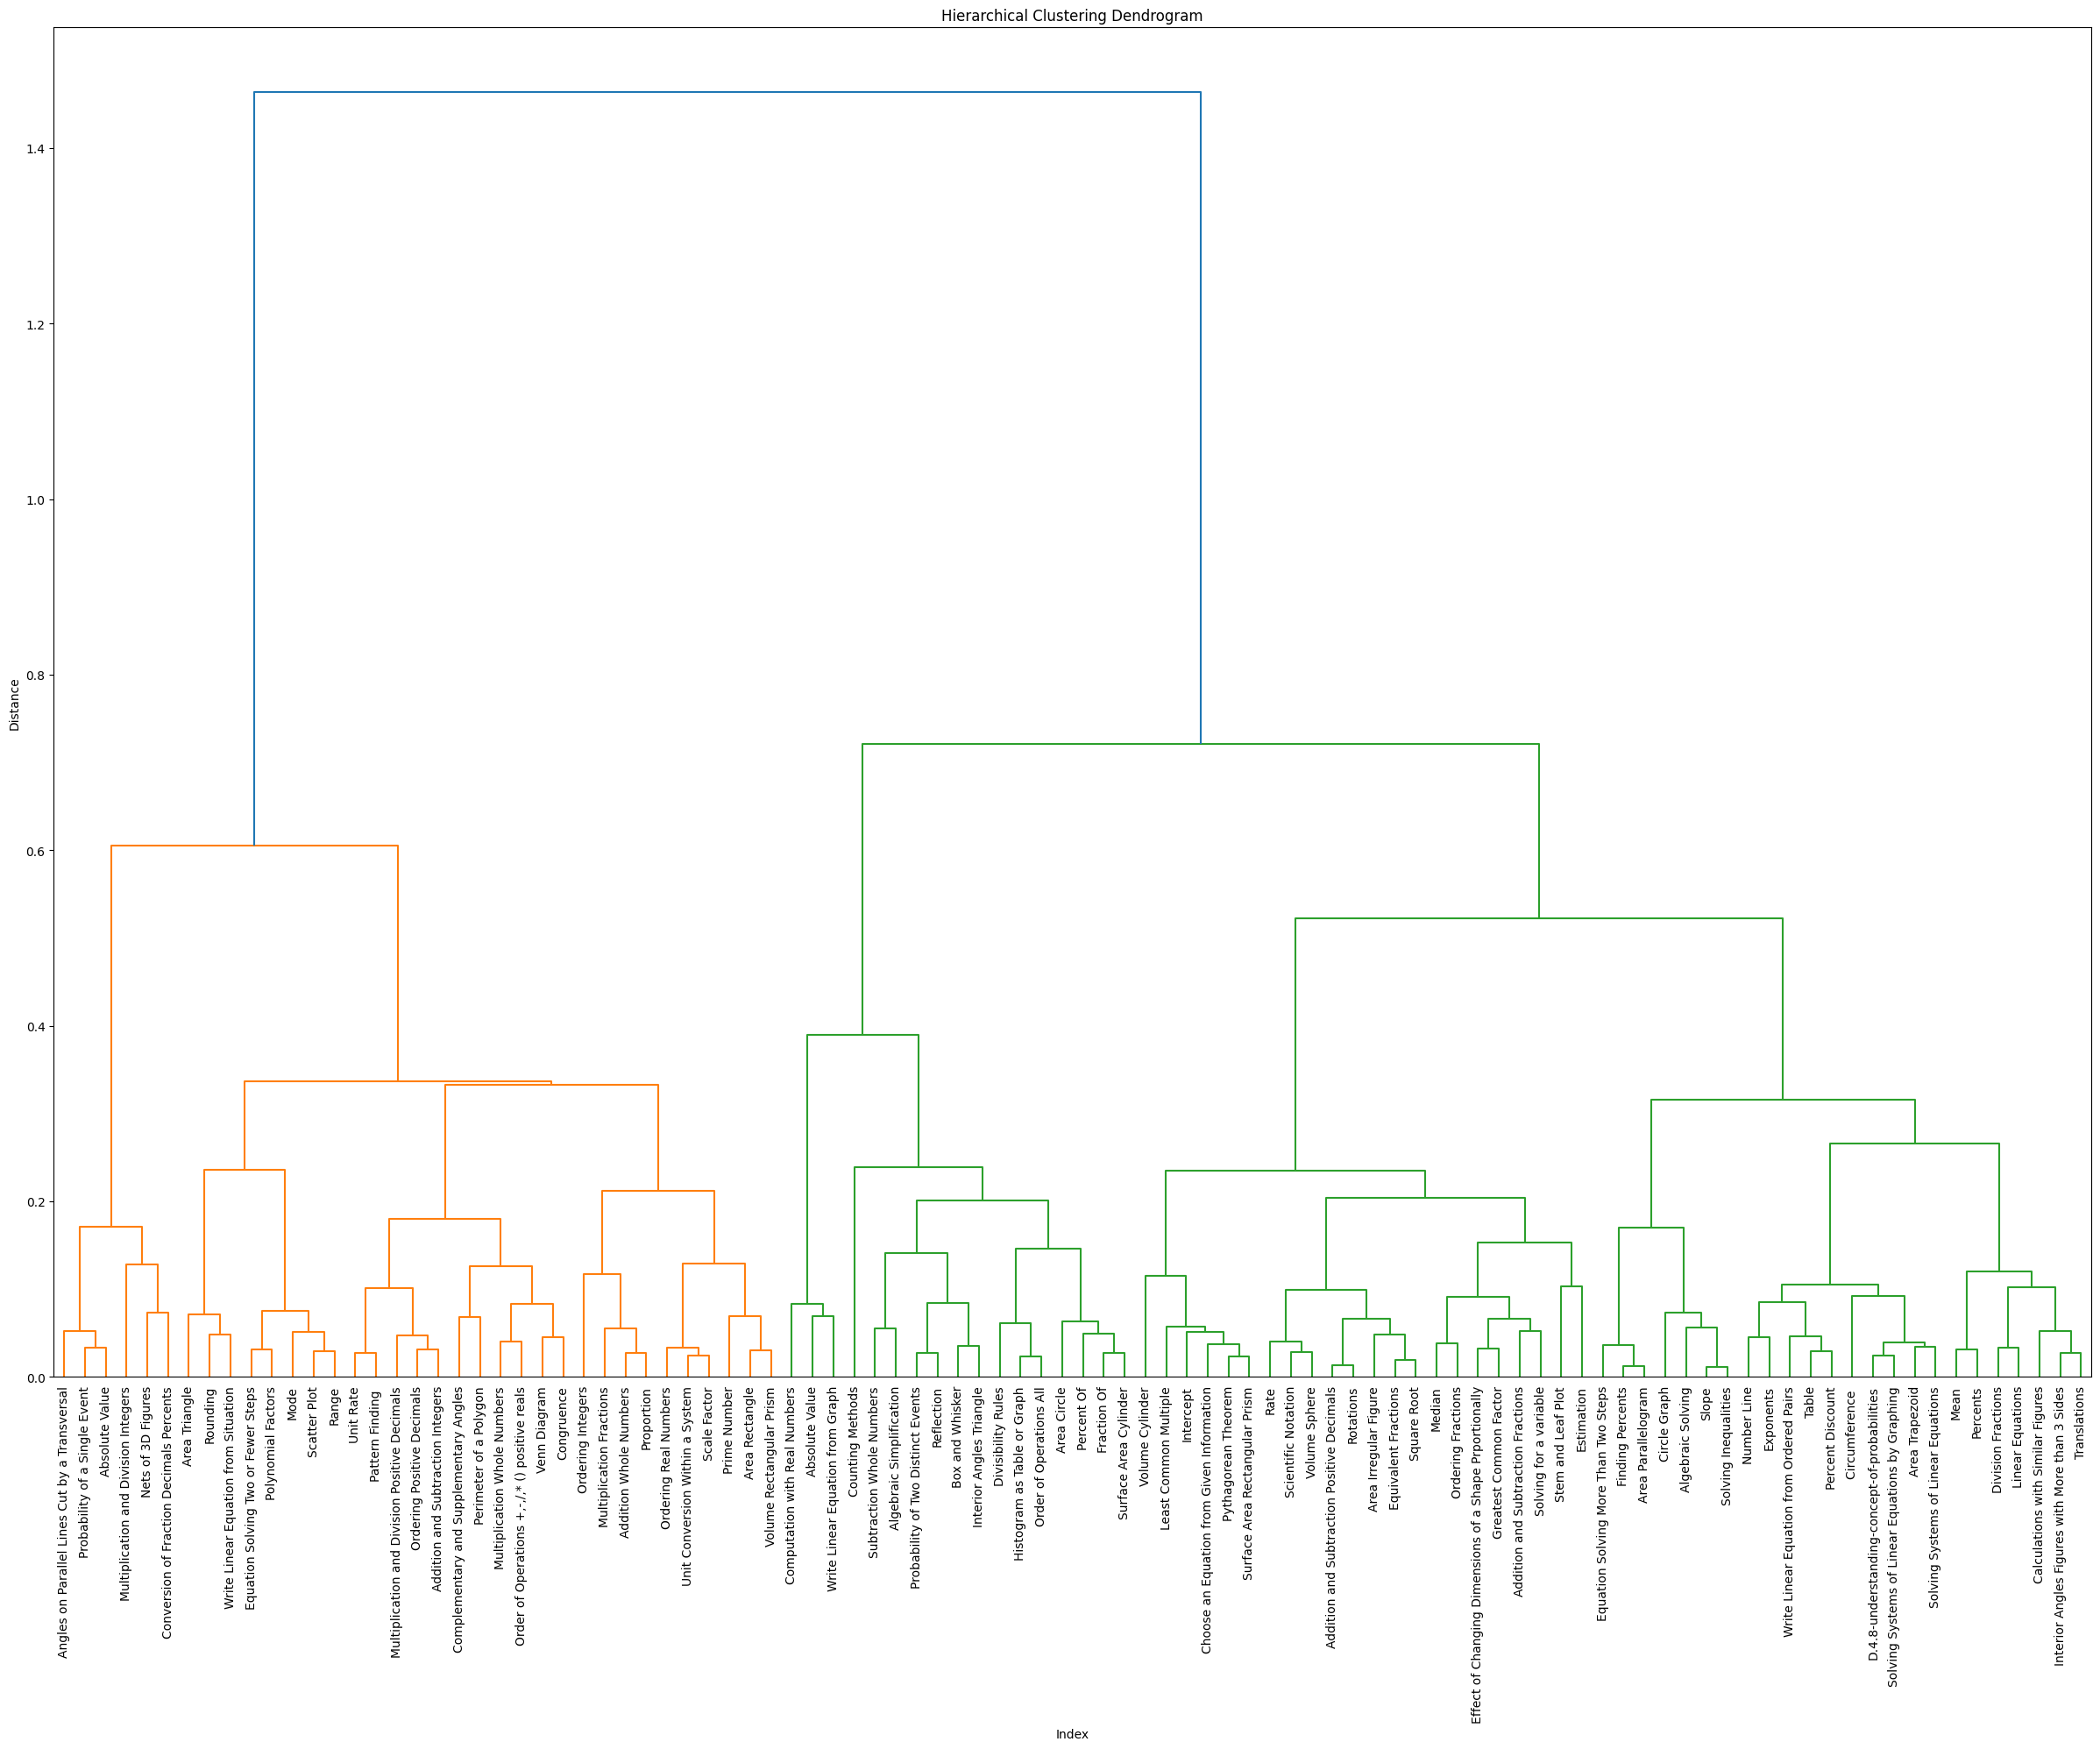

In [47]:
# Calculate the linkage matrix
linkage_matrix = sch.linkage(df_embeddings[['embed_1', 'embed_2', 'embed_3']], method='ward')

# Plot the dendrogram
plt.figure(figsize=(30, 20))
sch.dendrogram(linkage_matrix, labels=df_embeddings['skill_name'].values, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.show()
